In [1]:
# Instalamos kagglehub para descargar el dataset directamente desde Kaggle
# También instalamos las librerías necesarias para trabajar con PyTorch y métricas

!pip install -q kagglehub
!pip install -q torch torchvision scikit-learn tqdm

In [2]:
# Librerías para trabajar con archivos y carpetas
import os
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as T
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Mostrar la versión
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu128


In [3]:
import kagglehub

# Descargamos el dataset Fast Food Classification

path = kagglehub.dataset_download(
    "utkarshsaxenadn/fast-food-classification-dataset"
)

# Ruta donde quedó guardado el dataset
print("Dataset descargado en:")
print(path)

100%|██████████| 821M/821M [00:09<00:00, 92.0MB/s]

Extracting files...


Dataset descargado en:
/root/.cache/kagglehub/datasets/utkarshsaxenadn/fast-food-classification-dataset/versions/2


In [4]:
for root, dirs, files in os.walk(path):
    # Calculamos qué tan profunda está cada carpeta
    nivel = root.replace(path, "").count(os.sep)

    if nivel <= 2:
        sangria = "    " * nivel

        print(f"{sangria}{os.path.basename(root)}/")

2/
    Fast Food Classification V2/
        Test/
        Train/
        Valid/
        TFRecords/


In [5]:
# Creamos las transformaciones básicas para nuestra CNN

transform_basic = T.Compose([

    # Mismo tamaño para todos
    T.Resize((128, 128)),

    # Los valores de los píxeles pasan al rango 0 - 1
    T.ToTensor()
])

In [6]:
train_path = os.path.join(
    path,
    "Fast Food Classification V2",
    "Train"
)

dataset_completo = ImageFolder(root=train_path, transform=transform_basic)

# Mostramos las clases encontradas
print("Clases encontradas:")
print(dataset_completo.classes)

# Mostramos la cantidad total de imágenes
print("\nCantidad total:", len(dataset_completo))

Clases encontradas:
['Baked Potato', 'Burger', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Pizza', 'Sandwich', 'Taco', 'Taquito']

Cantidad total: 15000


In [7]:
MAX_IMAGENES = 10000 # La cantidad de imagenes maxima
indices = list(
    range(len(dataset_completo))
)

# Mezclamos aleatoriamente los índices
# Usamos una semilla para que el resultado pueda reproducirse

random.seed(42)
random.shuffle(indices)

# Nos quedamos únicamente con un máximo de 10 000 imágenes
indices = indices[:MAX_IMAGENES]

# Creamos un subconjunto del dataset
dataset_reducido = Subset(dataset_completo, indices)

# Mostramos la cantidad final
print("Imágenes utilizadas:", len(dataset_reducido))

Imágenes utilizadas: 10000


In [8]:
total = len(dataset_reducido)

# 70 % para entrenamiento
n_train = int(total * 0.70)

# 15 % para validación
n_val = int(total * 0.15)

# El resto será utilizado para prueba
n_test = total - n_train - n_val

# Dividimos aleatoriamente el dataset
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset_reducido,
    [n_train, n_val, n_test],
    # Semilla para poder reproducir exactamente la misma división
    generator=torch.Generator().manual_seed(42)
)

# Mostramos los tamaños
print("Train:", len(train_dataset))

print("Validation:", len(val_dataset))

print("Test:", len(test_dataset))

Train: 7000
Validation: 1500
Test: 1500


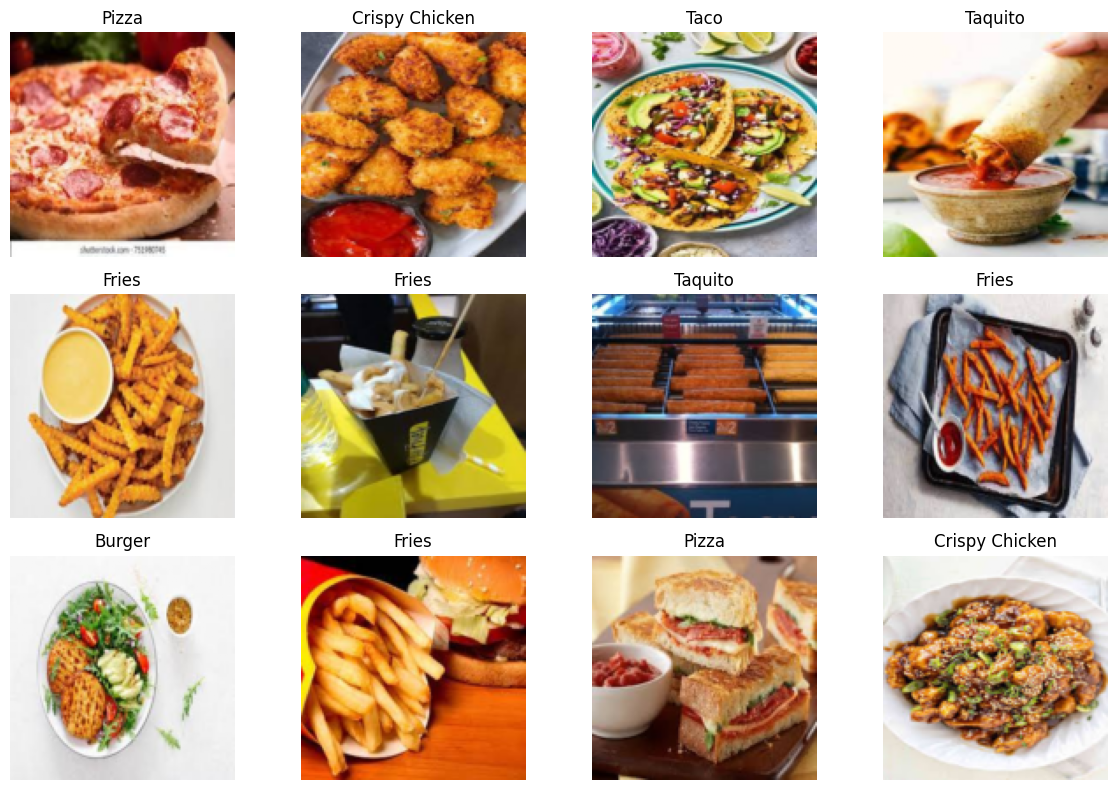

In [9]:
def show_batch(dataset, n=12):

    plt.figure(
        figsize=(12, 8)
    )

    for i in range(n):

        x, y = dataset[i]
        img = x.permute(1, 2,0)
        plt.subplot( 3, 4, i + 1)
        plt.imshow(img)
        plt.title(dataset_completo.classes[y])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Mostramos 12 imágenes
show_batch(train_dataset, n=12)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

Dispositivo: cuda


In [11]:
# Definimos cuántas imágenes procesará el modelo al mismo tiempo

batch_size = 64

# DataLoader para entrenamiento
# shuffle=True mezcla las imágenes en cada época

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Para validación no necesitamos mezclar los datos

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# DataLoader para las imágenes de prueba

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Obtenemos un batch para verificar las dimensiones

imagenes, etiquetas = next(iter(train_loader))

print("Forma de las imágenes:", imagenes.shape)

print("Forma de las etiquetas:", etiquetas.shape)

Forma de las imágenes: torch.Size([64, 3, 128, 128])
Forma de las etiquetas: torch.Size([64])


In [12]:
# Obtenemos la cantidad de clases automáticamente

num_classes = len(dataset_completo.classes)

print("Número de clases:", num_classes)

print("Clases:", dataset_completo.classes)

Número de clases: 10
Clases: ['Baked Potato', 'Burger', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Pizza', 'Sandwich', 'Taco', 'Taquito']


In [13]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        # Parte encargada de realizar la clasificación
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):
        # Extraemos características
        x = self.features(x)

        # Realizamos la clasificación
        x = self.classifier(x)

        return x


# Creamos el modelo
model_scratch = SimpleCNN(num_classes=num_classes).to(device)

# Mostramos su arquitectura
print(model_scratch)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [14]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()
    running_loss = 0.0

    for x, y in tqdm(loader):
        x = x.to(device)
        y = y.to(device).long()

        # Eliminamos gradientes anteriores
        optimizer.zero_grad()

        # El modelo genera las predicciones
        logits = model(x)

        # Calculamos la pérdida
        loss = criterion(logits, y)

        # Calculamos los gradientes
        loss.backward()

        # Actualizamos los pesos de la red
        optimizer.step()

        # Acumulamos la pérdida
        running_loss += (loss.item() * x.size(0))

    # Calculamos la pérdida promedio
    epoch_loss = (running_loss / len(loader.dataset))

    return epoch_loss

In [15]:
@torch.no_grad()
def evaluate(model, loader, criterion=None):

    model.eval()

    # Listas donde almacenaremos los resultados
    all_labels = []
    all_probs = []
    all_preds = []

    # Variable para acumular la pérdida
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        # Obtenemos la salida del modelo
        logits = model(x)

        # Calculamos la pérdida si se recibe criterion
        if criterion is not None:
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

        # Convertimos los logits en probabilidades
        probs = torch.softmax(logits, dim=1)

        # Seleccionamos la clase con mayor probabilidad
        preds = torch.argmax(probs, dim=1)

        # Guardamos las etiquetas reales
        all_labels.extend(y.cpu().numpy())

        # Guardamos las predicciones
        all_preds.extend(preds.cpu().numpy())

        # Guardamos todas las probabilidades
        all_probs.extend(probs.cpu().numpy())

    # Convertimos las listas en arrays
    all_labels = np.array(all_labels)

    all_preds = np.array(all_preds)

    all_probs = np.array(all_probs)

    # Calculamos Accuracy
    accuracy = accuracy_score(all_labels, all_preds)

    # Calculamos ROC-AUC multiclase
    try:
        auc = roc_auc_score(
            all_labels,
            all_probs,
            multi_class="ovr",
            average="macro"
        )

    # Si por alguna razón no se puede calcular
    except ValueError:
        auc = np.nan

    # Calculamos la pérdida promedio
    if criterion is not None:
        avg_loss = total_loss / len(loader.dataset)

    else:
        avg_loss = None

    return (
        avg_loss,
        accuracy,
        auc,
        all_labels,
        all_preds,
        all_probs
    )

In [17]:
criterion = nn.CrossEntropyLoss()

# Utilizamos Adam para actualizar los pesos
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

# Número de épocas que entrenará el modelo
epochs = 50

# Diccionario donde guardaremos las métricas de cada época
history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    # Entrenamos el modelo durante una época
    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    # Evaluamos el modelo con los datos de validación
    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model_scratch,
        val_loader,
        criterion
    )

    # Guardamos la pérdida de entrenamiento
    history_scratch["train_loss"].append(train_loss)

    # Guardamos la pérdida de validación
    history_scratch["val_loss"].append(val_loss)

    # Guardamos el Accuracy de validación
    history_scratch["val_acc"].append(val_acc)

    # Guardamos el ROC-AUC de validación
    history_scratch["val_auc"].append(val_auc)

    # Mostramos los resultados obtenidos en cada época
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

 25%|██▍       | 27/110 [00:07<00:14,  5.59it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 38%|███▊      | 42/110 [00:09<00:10,  6.77it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 110/110 [00:17<00:00,  6.36it/s]


Epoch 01 | train_loss=2.2909 | val_loss=2.2562 | val_acc=0.1487 | val_auc=0.5939


 56%|█████▋    | 62/110 [00:06<00:07,  6.64it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 110/110 [00:11<00:00,  9.17it/s]


Epoch 02 | train_loss=2.2280 | val_loss=2.2080 | val_acc=0.1740 | val_auc=0.6194


  1%|          | 1/110 [00:00<00:26,  4.12it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 53%|█████▎    | 58/110 [00:06<00:10,  5.01it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 110/110 [00:12<00:00,  9.02it/s]


...

Epoch 48 | train_loss=1.6064 | val_loss=1.6383 | val_acc=0.4633 | val_auc=0.8380


 26%|██▋       | 29/110 [00:02<00:06, 11.79it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 110/110 [00:11<00:00,  9.24it/s]


Epoch 49 | train_loss=1.6086 | val_loss=1.6395 | val_acc=0.4613 | val_auc=0.8365


  5%|▍         | 5/110 [00:00<00:10,  9.92it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 110/110 [00:12<00:00,  9.09it/s]


Epoch 50 | train_loss=1.5922 | val_loss=1.6611 | val_acc=0.4453 | val_auc=0.8373


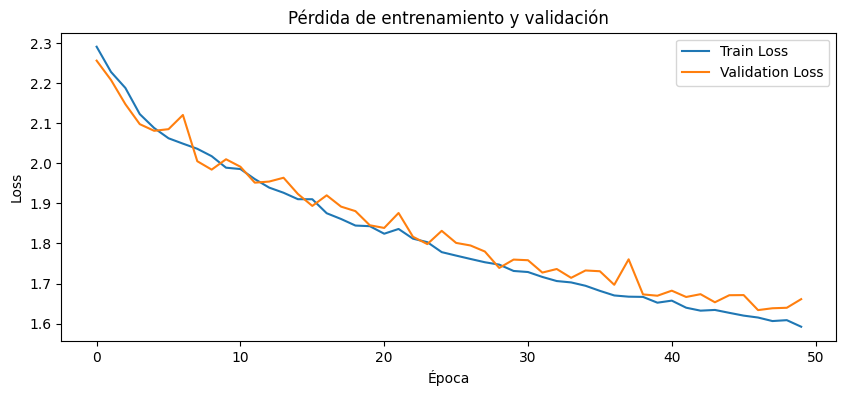

In [18]:
# =============================
# GRÁFICO DE PÉRDIDA
# =============================

plt.figure(figsize=(10, 4))

# Mostramos la pérdida de entrenamiento
plt.plot(
    history_scratch["train_loss"],
    label="Train Loss"
)

# Mostramos la pérdida de validación
plt.plot(
    history_scratch["val_loss"],
    label="Validation Loss"
)

plt.title("Pérdida de entrenamiento y validación")

plt.xlabel("Época")

plt.ylabel("Loss")

plt.legend()

plt.show()

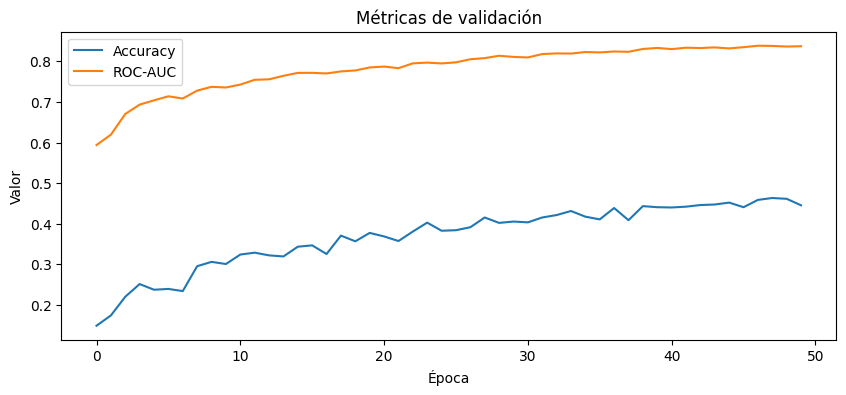

In [19]:
# =============================
# GRÁFICO DE MÉTRICAS
# =============================

plt.figure(figsize=(10, 4))

# Accuracy de validación
plt.plot(history_scratch["val_acc"], label="Accuracy")

# ROC-AUC de validación
plt.plot(history_scratch["val_auc"], label="ROC-AUC")

plt.title("Métricas de validación")

plt.xlabel("Época")

plt.ylabel("Valor")

plt.legend()

plt.show()

In [21]:
# Modelo con el conjunto de prueba
test_loss, test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader, criterion)

# Metricas principales
print(f"Test Loss: {test_loss:.4f}")

print(f"Test Accuracy: {test_acc:.4f}")

print(f"Test ROC-AUC: {test_auc:.4f}")

print()

# Reporte detallado por cada categoría
print(
    classification_report(
        y_true,
        y_pred,
        target_names=dataset_completo.classes,
        digits=4
    )
)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

Test Loss: 1.7001
Test Accuracy: 0.4387
Test ROC-AUC: 0.8293

                precision    recall  f1-score   support

  Baked Potato     0.5000    0.3791    0.4312       153
        Burger     0.4341    0.4000    0.4164       140
Crispy Chicken     0.4247    0.5849    0.4921       159
         Donut     0.3935    0.8777    0.5434       139
         Fries     0.5188    0.4859    0.5018       142
       Hot Dog     0.4231    0.1467    0.2178       150
         Pizza     0.5369    0.5263    0.5316       152
      Sandwich     0.3014    0.3165    0.3088       139
          Taco     0.4397    0.3129    0.3656       163
       Taquito     0.4846    0.3865    0.4300       163

      accuracy                         0.4387      1500
     macro avg     0.4457    0.4417    0.4239      1500
  weighted avg     0.4472    0.4387    0.4236      1500



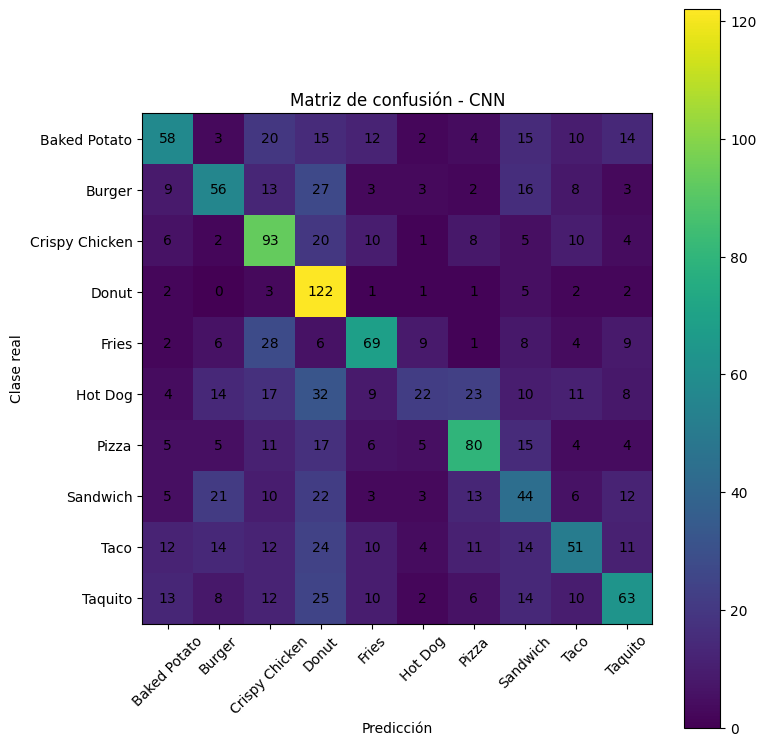

In [22]:
plt.figure(figsize=(8, 8))
plt.imshow(cm)

plt.title("Matriz de confusión - CNN")
plt.xlabel("Predicción")
plt.ylabel("Clase real")

# Nombres de las categorías
plt.xticks(
    range(num_classes),
    dataset_completo.classes,
    rotation=45
)

plt.yticks(
    range(num_classes),
    dataset_completo.classes
)

# Numero de ejemplos dentro de cada posición de la matriz

for i in range(num_classes):
    for j in range(num_classes):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

# Escala
plt.colorbar()
plt.tight_layout()
plt.show()

In [23]:
transform_aug = T.Compose([
    T.Resize((128, 128)),

    # Rotacion aleatoria de la imagen, hasta un máximo de 10 grados hacia cualquier lado
    T.RandomRotation(degrees=10),

    # Desplazamiento ligero de la imagen, hasta un 5 % en horizontal o vertical
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),

    # Algunas imágenes se voltearán horizontalmente con una probabilidad del 50 %
    T.RandomHorizontalFlip(p=0.5),

    # Convertimos la imagen a tensor
    T.ToTensor()
])

In [24]:
# Cargamos el dataset de entrenamiento, pero ahora utilizando data argumentation
train_dataset_aug = ImageFolder(root=train_path, transform=transform_aug)

# Cantidad de imágenes
print("Cantidad de imágenes:", len(train_dataset_aug))

Cantidad de imágenes: 15000


In [25]:
train_indices = [
    dataset_reducido.indices[i]
    for i in train_dataset.indices
]

# Subconjunto de entrenamiento con data augmentation
train_dataset_aug = Subset(train_dataset_aug, train_indices)

# Cantidad de imágenes
print("Cantidad de imágenes con Data Augmentation:", len(train_dataset_aug))

Cantidad de imágenes con Data Augmentation: 7000


In [26]:
# Creacion del dataloader
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

# Cantidad de batches
print("Cantidad de batches:", len(train_loader_aug))

Cantidad de batches: 55


In [27]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)

# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizador
optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

print(model_aug)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [28]:
# Número de épocas
epochs = 60

# Diccionario donde guardaremos las métricas
history_aug = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):

    # Entrenamos el modelo con Data Augmentation
    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer_aug,
        criterion
    )

    # Evaluamos con los mismos datos de validación
    val_loss, val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader,
        criterion
    )

    # Guardamos la pérdida de entrenamiento
    history_aug["train_loss"].append(train_loss)

    # Guardamos la pérdida de validación
    history_aug["val_loss"].append(val_loss)

    # Guardamos el Accuracy
    history_aug["val_acc"].append(val_acc)

    # Guardamos el ROC-AUC
    history_aug["val_auc"].append(val_auc)

    # Mostramos los resultados
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

  2%|▏         | 1/55 [00:00<00:28,  1.88it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 55/55 [00:20<00:00,  2.74it/s]


Epoch 01 | train_loss=2.3006 | val_loss=2.2846 | val_acc=0.1420 | val_auc=0.5794


 29%|██▉       | 16/55 [00:05<00:11,  3.30it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 55/55 [00:18<00:00,  2.92it/s]


Epoch 02 | train_loss=2.2535 | val_loss=2.2286 | val_acc=0.1800 | val_auc=0.6001


 51%|█████     | 28/55 [00:09<00:08,  3.31it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 55/55 [00:18<00:00,  2.91it/s]


...

Epoch 58 | train_loss=1.6813 | val_loss=1.7065 | val_acc=0.4280 | val_auc=0.8250


  9%|▉         | 5/55 [00:01<00:17,  2.87it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 55/55 [00:18<00:00,  2.99it/s]


Epoch 59 | train_loss=1.6812 | val_loss=1.7399 | val_acc=0.4153 | val_auc=0.8185


 55%|█████▍    | 30/55 [00:10<00:07,  3.26it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 55/55 [00:18<00:00,  2.93it/s]


Epoch 60 | train_loss=1.6780 | val_loss=1.7076 | val_acc=0.4293 | val_auc=0.8240


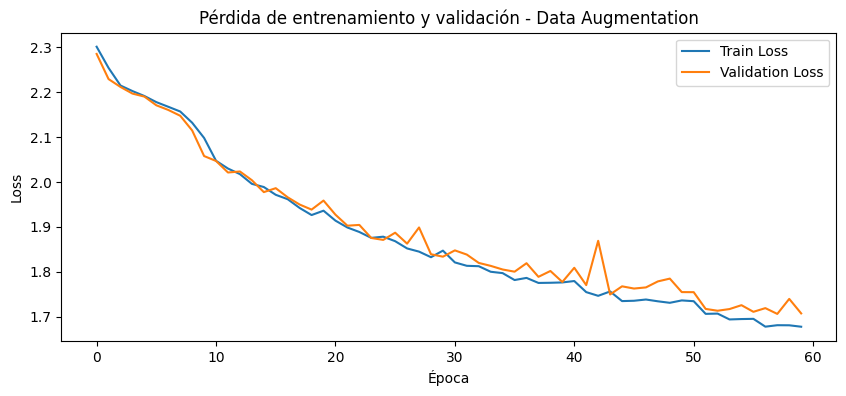

In [30]:
# =============================
# GRÁFICO DE PÉRDIDA
# =============================

plt.figure(figsize=(10, 4))

# Pérdida de entrenamiento
plt.plot(
    history_aug["train_loss"],
    label="Train Loss"
)

# Pérdida de validación
plt.plot(
    history_aug["val_loss"],
    label="Validation Loss"
)

plt.title("Pérdida de entrenamiento y validación - Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

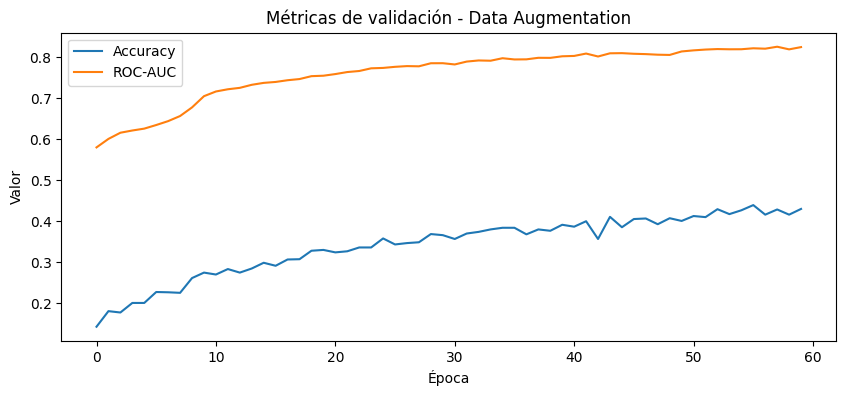

In [31]:
# =============================
# GRÁFICO DE MÉTRICAS
# =============================

plt.figure(figsize=(10, 4))

# Accuracy de validación
plt.plot(
    history_aug["val_acc"],
    label="Accuracy"
)

# ROC-AUC de validación
plt.plot(
    history_aug["val_auc"],
    label="ROC-AUC"
)

plt.title("Métricas de validación - Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

In [32]:
# Evaluamos el modelo con Data Augmentation
test_loss_aug, test_acc_aug, test_auc_aug, y_true_aug, y_pred_aug, y_prob_aug = evaluate(
    model_aug,
    test_loader,
    criterion
)

# Métricas principales
print(f"Test Loss: {test_loss_aug:.4f}")
print(f"Test Accuracy: {test_acc_aug:.4f}")
print(f"Test ROC-AUC: {test_auc_aug:.4f}")

Test Loss: 1.7242
Test Accuracy: 0.4420
Test ROC-AUC: 0.8172


In [33]:
# =============================
# COMPARACIÓN DE MODELOS
# =============================

print("CNN sin Data Augmentation")
print(f"Accuracy: {test_acc:.4f}")
print(f"ROC-AUC: {test_auc:.4f}")

print()

print("CNN con Data Augmentation")
print(f"Accuracy: {test_acc_aug:.4f}")
print(f"ROC-AUC: {test_auc_aug:.4f}")

CNN sin Data Augmentation
Accuracy: 0.4387
ROC-AUC: 0.8293

CNN con Data Augmentation
Accuracy: 0.4420
ROC-AUC: 0.8172


Conclusion:
El Data Augmentation produjo una mejora mínima en el Accuracy, pero redujo el ROC-AUC. Por lo tanto, no se observa una mejora clara del modelo con las transformaciones aplicadas.